In [1]:
import numpy as np
import pandas as pd
from kneed import KneeLocator
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

🔵 LOAD ALL DFS (FEATURES AND CLINICAL BIOMARKERS)

In [2]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})
clinical_df = clinical_df.dropna(subset=['Stage'])
clinical_df['Stage'] = clinical_df['Stage'].astype(int)

df_c25 = pd.read_csv(r"D:\CSV\merged\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_vmi40 = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi80 = pd.read_csv(r"D:\CSV\merged\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi120 = pd.read_csv(r"D:\CSV\merged\merged_monoe_120kev_radiomics_spine_lesions_features.csv")
df_konv = pd.read_csv(r"D:\CSV\merged\merged_konv_radiomics_spine_lesions_features.csv")

🔵 TRAIN AND TEST MODEL BASED ON IMAGE FEATURES FOR EVERY DF

In [3]:
# dfs = [df_c25, df_konv, df_vmi40, df_vmi80, df_vmi120]
# dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']

clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")

pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})
clinical_df = clinical_df.dropna(subset=['Stage'])
clinical_df['Stage'] = clinical_df['Stage'].astype(int)

from feature_selection import Dataset
m = Dataset()._merged_csvs()

for name, df in m.items():

    if name == "CaSupp_25":

        X = df.select_dtypes(include=['number'])
        y = clinical_df['Stage']

        valid_idx = X.notna().all(axis=1) & y.notna()
        X = X[valid_idx]
        y = y[valid_idx]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        rf = RandomForestClassifier(n_estimators=300, random_state=42)
        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"Accuracy for df: {name}: {acc:.3f}")

        feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
        print(feature_importance_df)

    # cm = confusion_matrix(y_test, y_pred)
    # sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
    # plt.xlabel("Predicted")
    # plt.ylabel("Real one")
    # plt.title(f"Confusion Matrix for df: {name} - Random Forest")
    # plt.show()

        imp = np.sort(feature_importance_df['Importance'].values)[::-1]
        x = np.arange(1, len(imp) + 1)

        knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
        threshold = imp[knee.knee] if knee.knee is not None else None
        selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature'].tolist()
        print(f"Selected features: {selected_features}")

    # plt.figure(figsize=(10, 6))
    # plt.plot(x, imp, marker='o', label='Feature importance')
    # if threshold is not None:
    #     plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
    #     plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
    # plt.title(f"Feature importance curve for {name}\nAccuracy: {acc:.3f}")
    # plt.xlabel("Feature rank (sorted by importance)")
    # plt.ylabel("Importance")
    # plt.grid(True, linestyle='--', alpha=0.6)
    # plt.legend()
    # plt.tight_layout()
    # plt.show()


Accuracy for df: CaSupp_25: 0.786
                              Feature  Importance
108  gradient_firstorder_10Percentile    0.019027
29       original_firstorder_Skewness    0.017209
139                gradient_glcm_Imc1    0.016685
35         original_glcm_ClusterShade    0.014466
20       original_firstorder_Kurtosis    0.013943
..                                ...         ...
122      gradient_firstorder_Skewness    0.001353
181       gradient_glszm_ZoneVariance    0.001285
199           gradient_ngtdm_Contrast    0.001081
170  gradient_glszm_LargeAreaEmphasis    0.000934
109  gradient_firstorder_90Percentile    0.000326

[201 rows x 2 columns]
Selected features: ['gradient_firstorder_10Percentile', 'original_firstorder_Skewness', 'gradient_glcm_Imc1', 'original_glcm_ClusterShade', 'original_firstorder_Kurtosis', 'original_glcm_Id', 'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_RobustMeanAbsoluteDeviation', 'original_glszm_GrayLevelNonUniformityNormalized', 'or

🔵 TRAIN AND TEST MODEL BASED JUST ON CLINICAL BIOMARKER

In [64]:
X = clinical_df.select_dtypes(include=['number']).drop(columns='Stage')
y = clinical_df['Stage']

valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# rf = RandomForestClassifier(n_estimators=10, random_state=42)
#
# scores = cross_val_score(rf, X_train, y_train, cv=skf)  # 5-fold CV
# print("CV accuracy scores:", scores)
# print("Mean accuracy:", scores.mean())

rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
# plt.xlabel("Predicted")
# plt.ylabel("Real one")
# plt.title(f"Confusion Matrix - Random Forest")
# plt.show()

Accuracy: 1.000


🔵 IMPORTANCE OF FEATURES FROM RANDOM FOREST MODEL

                            Feature  Importance
9        Beta2 microglobulin (mg/l)    0.425441
8         Creatinine level (µmol/l)    0.138436
7      Calcium total level (mmol/l)    0.088341
1    Serum kappa FLC quantity (mg/l    0.083309
6           Plasmocyte count FC (%)    0.067146
0    Serum M-protein quantity (g/l)    0.060407
4                IgA quantity (g/l)    0.052786
5                IgM quantity (g/l)    0.045965
2  Serum lambda FLC quantity (mg/l)    0.019464
3                IgG quantity (g/l)    0.018705
Selected features: ['Beta2 microglobulin (mg/l)', 'Creatinine level (µmol/l)', 'Calcium total level (mmol/l)']


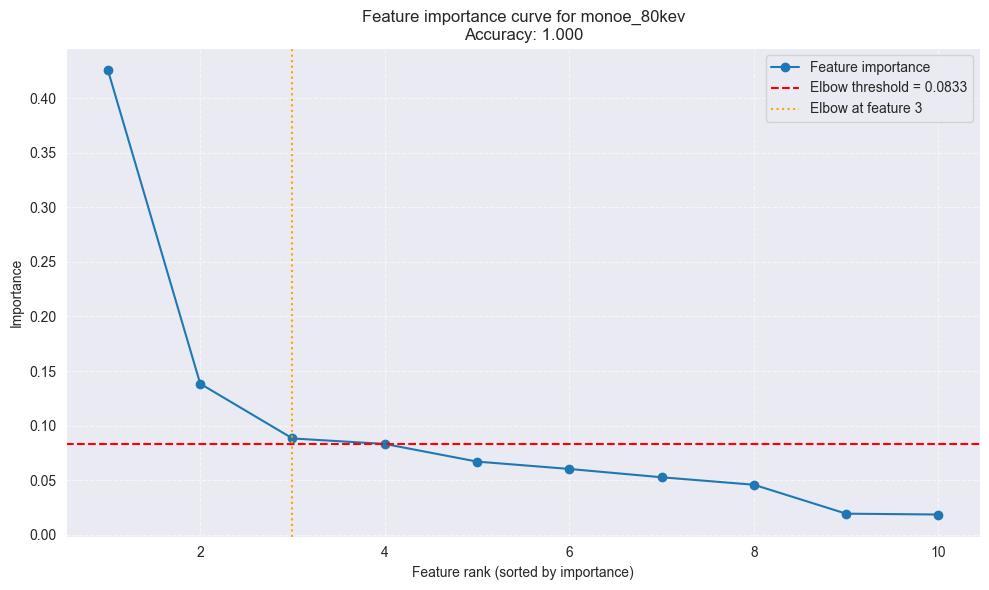

In [65]:
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)

imp = np.sort(feature_importance_df['Importance'].values)[::-1]
x = np.arange(1, len(imp) + 1)

knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
threshold = imp[knee.knee] if knee.knee is not None else None
selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature'].tolist()
print(f"Selected features: {selected_features}")

plt.figure(figsize=(10, 6))
plt.plot(x, imp, marker='o', label='Feature importance')
if threshold is not None:
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
    plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
plt.title(f"Feature importance curve for {name}\nAccuracy: {acc:.3f}")
plt.xlabel("Feature rank (sorted by importance)")
plt.ylabel("Importance")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

🔵 RANDOM FOREST USING SELECTED FEATURES FROM K-W test (at least 2 significant result from 3 pairs)

In [12]:
kw_c25 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_CaSupp_25.csv")
kw_konv = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_konv.csv")
kw_vmi40 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi40.csv")
kw_vmi80 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi80.csv")
kw_vmi120 = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi120.csv")

# significant_c25 = kw_c25[(kw_c25[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
# significant_konv = kw_konv[(kw_konv[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
# significant_vmi40 = kw_vmi40[(kw_vmi40[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
# significant_vmi80 = kw_vmi80[(kw_vmi80[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']
# significant_vmi120 = kw_vmi120[(kw_vmi120[['p(1-2)', 'p(1-3)', 'p(2-3)']] < 0.05).sum(axis=1) >= 2]['Feature']

significant_c25 = kw_c25[(kw_c25['p_all'] < 0.05)]['Feature']
significant_konv = kw_konv[(kw_konv['p_all'] < 0.05)]['Feature']
significant_vmi40 = kw_vmi40[(kw_vmi40['p_all'] < 0.05)]['Feature']
significant_vmi80 = kw_vmi80[(kw_vmi80['p_all'] < 0.05)]['Feature']
significant_vmi120 = kw_vmi120[(kw_vmi120['p_all'] < 0.05)]['Feature']

Accuracy for df: CaSupp_25 with significant features based on K-W test: 0.714
                             Feature  Importance
49  gradient_firstorder_10Percentile    0.026421
13        original_glcm_ClusterShade    0.024489
72                gradient_glcm_Imc1    0.023388
9       original_firstorder_Skewness    0.022532
63        gradient_glcm_ClusterShade    0.020705
Selected features: ['gradient_firstorder_10Percentile', 'original_glcm_ClusterShade', 'gradient_glcm_Imc1', 'original_firstorder_Skewness', 'gradient_glcm_ClusterShade', 'gradient_glcm_Imc2', 'original_firstorder_Variance', 'original_firstorder_RootMeanSquared', 'original_glrlm_GrayLevelVariance', 'gradient_gldm_LowGrayLevelEmphasis', 'original_firstorder_10Percentile', 'gradient_glrlm_RunEntropy']


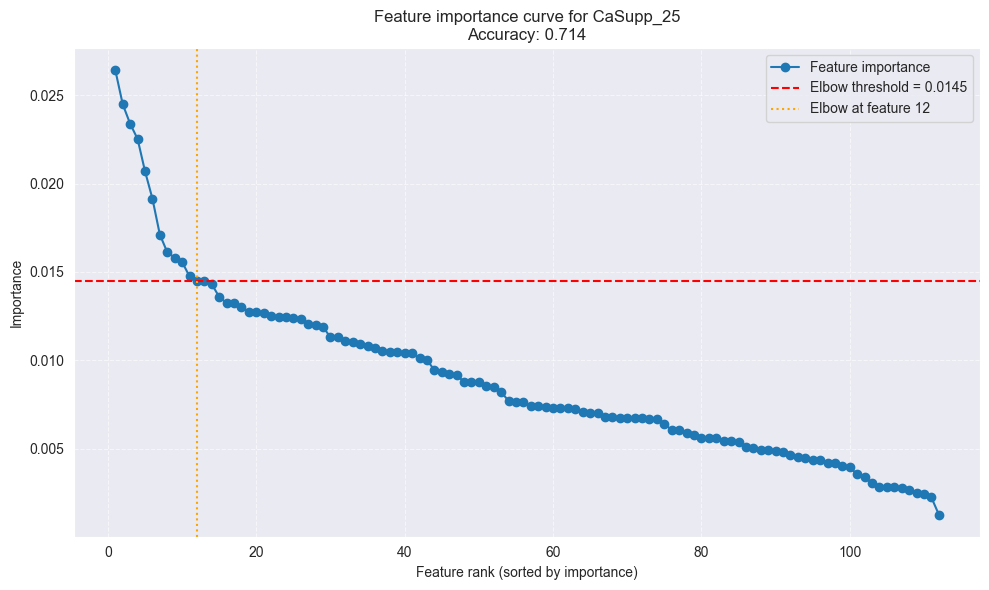

Accuracy for df: Konv with significant features based on K-W test: 0.571
                                Feature  Importance
44     gradient_firstorder_10Percentile    0.025700
16                    original_glcm_Idn    0.021607
106  gradient_gldm_LowGrayLevelEmphasis    0.020950
98           gradient_glszm_ZoneEntropy    0.019547
38     original_gldm_DependenceVariance    0.019112
Selected features: ['gradient_firstorder_10Percentile', 'original_glcm_Idn', 'gradient_gldm_LowGrayLevelEmphasis', 'gradient_glszm_ZoneEntropy', 'original_gldm_DependenceVariance', 'gradient_glrlm_LowGrayLevelRunEmphasis', 'gradient_glcm_Imc2', 'gradient_glrlm_ShortRunEmphasis', 'gradient_glrlm_RunVariance', 'gradient_glszm_LowGrayLevelZoneEmphasis', 'original_ngtdm_Contrast', 'gradient_glcm_ClusterShade']


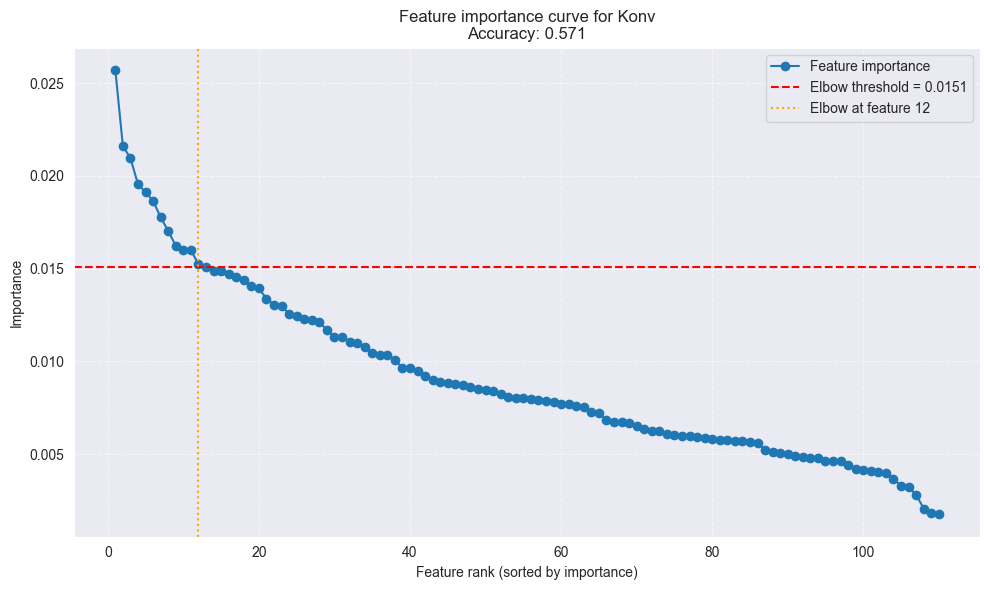

Accuracy for df: VMI_40 with significant features based on K-W test: 0.714
                                         Feature  Importance
2                   original_firstorder_Kurtosis    0.040443
70               gradient_glcm_ClusterProminence    0.024443
81                            gradient_glcm_Imc2    0.023006
5                   original_firstorder_Skewness    0.022103
103  gradient_glrlm_ShortRunLowGrayLevelEmphasis    0.017858
Selected features: ['original_firstorder_Kurtosis', 'gradient_glcm_ClusterProminence', 'gradient_glcm_Imc2', 'original_firstorder_Skewness', 'gradient_glrlm_ShortRunLowGrayLevelEmphasis', 'gradient_glrlm_GrayLevelVariance', 'original_glcm_Idm', 'gradient_glrlm_LongRunLowGrayLevelEmphasis', 'gradient_firstorder_Entropy', 'original_glcm_Id', 'original_glrlm_ShortRunEmphasis']


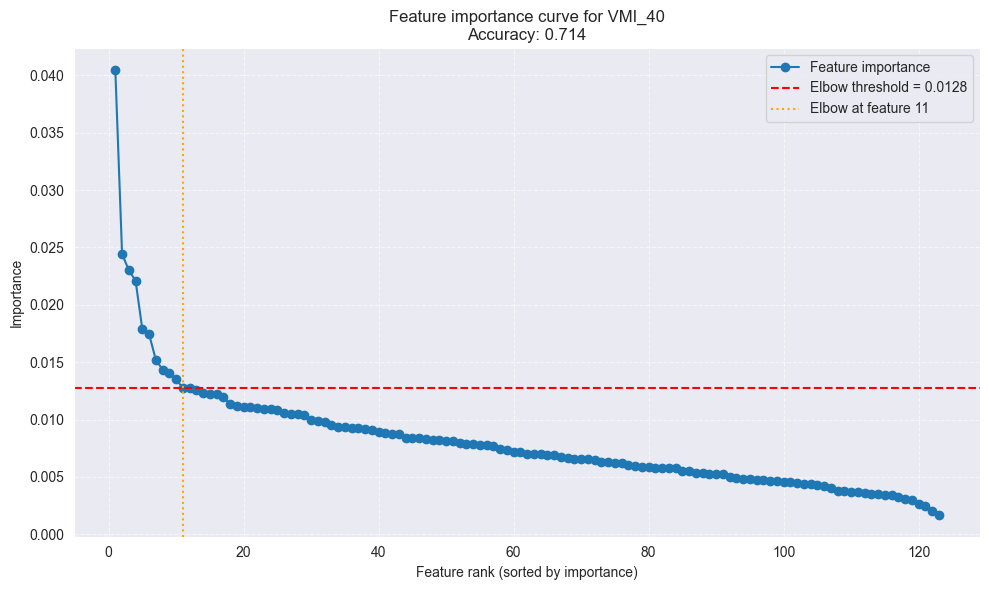

Accuracy for df: VMI_80 with significant features based on K-W test: 0.714
                                Feature  Importance
16                   original_glcm_Idmn    0.027233
93           gradient_glszm_ZoneEntropy    0.023507
17                    original_glcm_Idn    0.022573
101  gradient_gldm_LowGrayLevelEmphasis    0.019256
3          original_firstorder_Kurtosis    0.018621
Selected features: ['original_glcm_Idmn', 'gradient_glszm_ZoneEntropy', 'original_glcm_Idn', 'gradient_gldm_LowGrayLevelEmphasis', 'original_firstorder_Kurtosis', 'gradient_glcm_ClusterShade', 'gradient_glcm_ClusterProminence', 'gradient_glszm_GrayLevelVariance', 'original_ngtdm_Contrast', 'gradient_glszm_HighGrayLevelZoneEmphasis', 'gradient_gldm_DependenceVariance', 'gradient_gldm_LargeDependenceLowGrayLevelEmphasis']


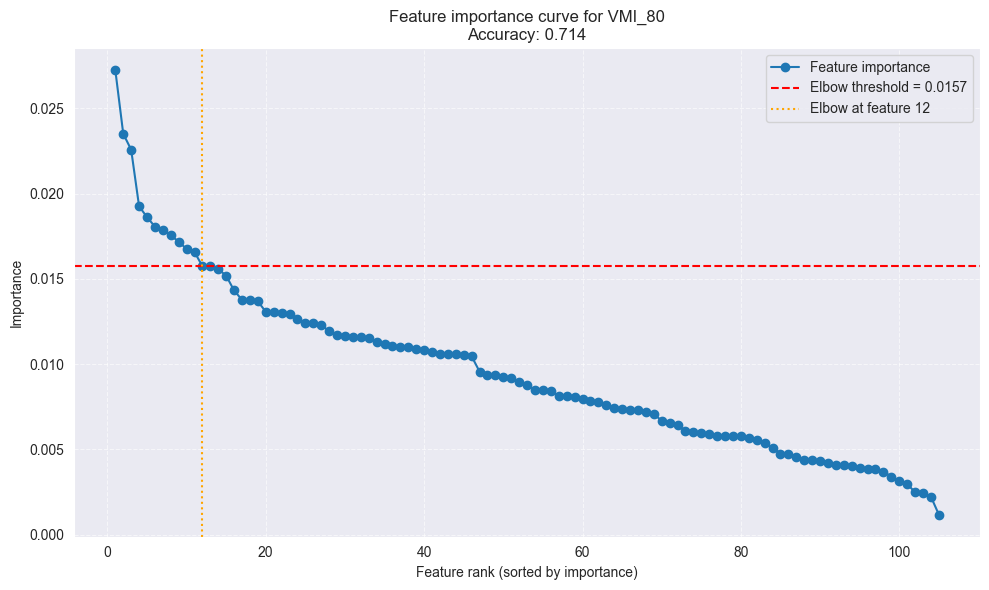

Accuracy for df: VMI_120 with significant features based on K-W test: 0.714
                                       Feature  Importance
37                     original_ngtdm_Contrast    0.028342
71  gradient_glrlm_LongRunLowGrayLevelEmphasis    0.027098
33            original_gldm_DependenceVariance    0.025777
85                  gradient_glszm_ZoneEntropy    0.022768
38            gradient_firstorder_10Percentile    0.021108
Selected features: ['original_ngtdm_Contrast', 'gradient_glrlm_LongRunLowGrayLevelEmphasis', 'original_gldm_DependenceVariance', 'gradient_glszm_ZoneEntropy', 'gradient_firstorder_10Percentile', 'gradient_glcm_ClusterShade', 'gradient_glszm_ZonePercentage', 'gradient_glcm_ClusterProminence', 'gradient_glrlm_RunVariance']


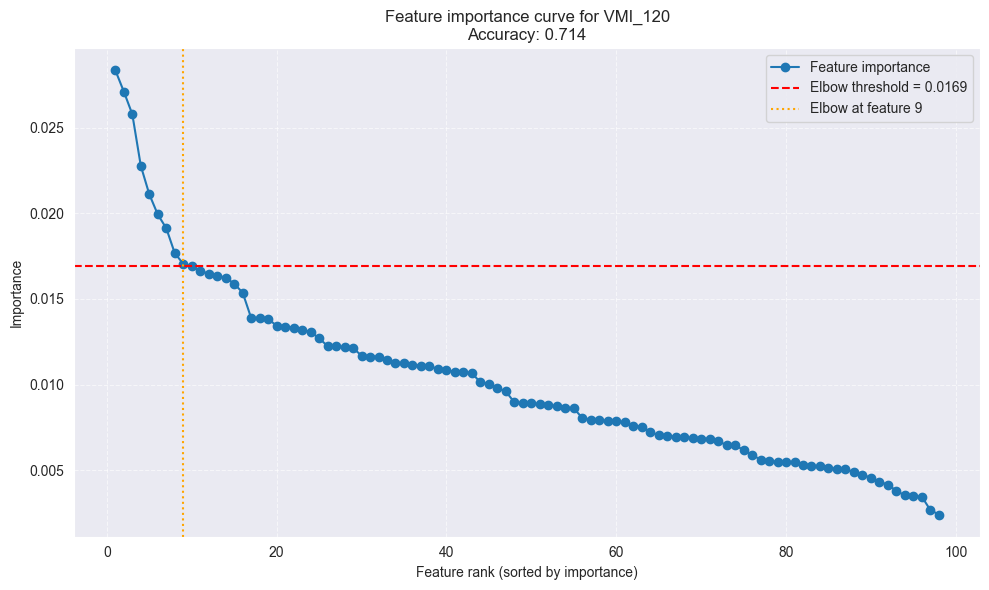

In [14]:
dfs = [df_c25, df_konv, df_vmi40, df_vmi80, df_vmi120]
dataset_names = ['CaSupp_25', 'Konv', 'VMI_40', 'VMI_80', 'VMI_120']
significant = [significant_c25, significant_konv, significant_vmi40, significant_vmi80, significant_vmi120]

for df, name, significant_features in zip(dfs, dataset_names, significant):

    X = df[significant_features].select_dtypes(include=['number'])
    y = clinical_df['Stage']

    valid_idx = X.notna().all(axis=1) & y.notna()
    X = X[valid_idx]
    y = y[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy for df: {name} with significant features based on K-W test: {acc:.3f}")
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
    print(feature_importance_df.head())

    # cm = confusion_matrix(y_test, y_pred)
    # sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[1,2,3], yticklabels=[1,2,3])
    # plt.xlabel("Predicted")
    # plt.ylabel("Real one")
    # plt.title(f"Confusion Matrix for df: {name} - Random Forest")
    # plt.show()

    imp = np.sort(feature_importance_df['Importance'].values)[::-1]
    x = np.arange(1, len(imp) + 1)

    knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
    threshold = imp[knee.knee] if knee.knee is not None else None
    selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature'].tolist()
    print(f"Selected features: {selected_features}")

    plt.figure(figsize=(10, 6))
    plt.plot(x, imp, marker='o', label='Feature importance')
    if threshold is not None:
        plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
        plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
    plt.title(f"Feature importance curve for {name}\nAccuracy: {acc:.3f}")
    plt.xlabel("Feature rank (sorted by importance)")
    plt.ylabel("Importance")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


🔵 RANDOM FOREST WITH ALL FEATURES THROUGH ALL IMAGE TYPES

In [66]:
from helper_files.feature_selection_helper import merged_lesions_csv, get_kruskal_wallis_csv

base_dir_path = r"D:\DATA_Myelomy"
clinical_biomarkers_path = r"D:\Clinical_data\Table_clinical_data.csv"

merged = merged_lesions_csv(base_dir_path)
kw = get_kruskal_wallis_csv(merged, clinical_biomarkers_path)

In [67]:
combined_df_list = []
for dataset_name, df in merged.items():

    numeric_df = df.select_dtypes(include=['number']).copy()
    numeric_df = numeric_df.add_prefix(f"{dataset_name}_")
    combined_df_list.append(numeric_df)

combined_df = pd.concat(combined_df_list, axis=1)
combined_df

,BMD_n_lesions,BMD_original_shape_Elongation,BMD_original_shape_Flatness,BMD_original_shape_LeastAxisLength,BMD_original_shape_MajorAxisLength,BMD_original_shape_Maximum2DDiameterColumn,BMD_original_shape_Maximum2DDiameterRow,BMD_original_shape_Maximum2DDiameterSlice,BMD_original_shape_Maximum3DDiameter,BMD_original_shape_MeshVolume,...,monoe_80kev_gradient_gldm_LargeDependenceLowGrayLevelEmphasis,monoe_80kev_gradient_gldm_LowGrayLevelEmphasis,monoe_80kev_gradient_gldm_SmallDependenceEmphasis,monoe_80kev_gradient_gldm_SmallDependenceHighGrayLevelEmphasis,monoe_80kev_gradient_gldm_SmallDependenceLowGrayLevelEmphasis,monoe_80kev_gradient_ngtdm_Busyness,monoe_80kev_gradient_ngtdm_Coarseness,monoe_80kev_gradient_ngtdm_Complexity,monoe_80kev_gradient_ngtdm_Contrast,monoe_80kev_gradient_ngtdm_Strength
0,42,0.208989,0.090847,48.159211,530.112286,489.628282,477.609470,70.013470,524.164765,3558.334557,...,10.958494,0.215969,0.150260,4.975312,0.023879,8.901407,0.001025,373.109539,0.014480,0.889986
1,26,0.312599,0.177995,56.369710,316.692125,312.249080,221.602910,62.017486,350.835395,9249.070315,...,30.042147,0.315859,0.088350,1.977885,0.015691,52.858414,0.000434,79.481747,0.018910,0.073252
2,8,0.212993,0.151570,36.779577,242.656717,119.996801,223.869005,26.654969,272.417997,1063.982617,...,15.295225,0.264689,0.113543,3.107458,0.021510,4.824119,0.003358,145.971692,0.017245,1.252462
3,54,0.159400,0.086384,43.732812,506.259109,448.915430,452.701719,83.059497,506.152358,29300.959604,...,35.156534,0.331646,0.113942,3.598346,0.016212,99.647918,0.000131,250.301284,0.014264,0.083218
4,12,0.192710,0.149551,57.235029,382.711335,214.831665,320.170141,47.350217,373.626743,3274.072115,...,11.211558,0.190617,0.125523,3.925351,0.018671,17.238918,0.001040,107.283384,0.032399,0.159752
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,89,0.233804,0.087668,45.004290,513.347438,402.978760,519.557773,91.077216,524.753774,26115.132076,...,24.886522,0.298153,0.098329,2.363982,0.018454,96.807489,0.000147,184.983242,0.011575,0.071391
68,74,0.204975,0.091256,38.972118,427.062695,369.135680,448.864329,69.583076,448.868578,57601.528562,...,15.724846,0.218892,0.156243,6.458687,0.018733,126.018146,0.000063,536.523306,0.019765,0.058542
69,27,0.101824,0.043274,26.700219,617.003616,382.426535,506.295135,41.068099,509.125937,4524.451179,...,18.675069,0.246674,0.101382,2.200123,0.020623,25.404090,0.000725,108.111115,0.016244,0.169699
70,50,0.181550,0.102740,42.502876,413.693927,370.293745,485.256220,74.276550,485.787949,69742.836838,...,21.295897,0.262232,0.090217,2.347879,0.017718,247.061179,0.000055,190.261930,0.011556,0.026382


In [68]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})
clinical_df = clinical_df.dropna(subset=['Stage'])
clinical_df['Stage'] = clinical_df['Stage'].astype(int)

X = combined_df
y = clinical_df['Stage']

valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# cm = confusion_matrix(y_test, y_pred)
# class_accuracies = []
# for i in range(len(cm)):
#     total = cm[i].sum()
#     correct = cm[i, i]
#     acc = correct / total if total > 0 else 0
#     class_accuracies.append(acc)
#
# accuracy_text = " | ".join([
#     f"Stage {i + 1}: {class_accuracies[i] * 100:.1f}%"
#     for i in range(len(class_accuracies))
# ])
#
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=[1, 2, 3], yticklabels=[1, 2, 3], cbar=False)
# plt.xlabel("Predicted")
# plt.ylabel("True label")
# plt.title(f"Confusion Matrix\n{accuracy_text}")
#
# imp = np.sort(feature_importance_df['Importance'].values)[::-1]
# x = np.arange(1, len(imp) + 1)
#
# knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
# threshold = imp[knee.knee] if knee.knee is not None else None
# selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature'].tolist()
# print(f"Selected features: {selected_features}")
#
# plt.figure(figsize=(10, 6))
# plt.plot(x, imp, marker='o', label='Feature importance')
# if threshold is not None:
#     plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
#     plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
# plt.title(f"Feature importance curve for all features combines\nAccuracy: {acc:.3f}")
# plt.xlabel("Feature rank (sorted by importance)")
# plt.ylabel("Importance")
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend()
# plt.tight_layout()
# plt.show()

Accuracy: 0.714
                                               Feature  Importance
824           monoe_40kev_original_firstorder_Kurtosis    0.014285
558    konv_gradient_glrlm_LongRunLowGrayLevelEmphasis    0.009022
1073          monoe_80kev_original_glrlm_RunPercentage    0.007262
711      monoe_120kev_gradient_firstorder_10Percentile    0.007153
237            CaSupp_25_original_glcm_ClusterTendency    0.006708
...                                                ...         ...
239                CaSupp_25_original_glcm_Correlation    0.000000
30                 BMD_original_firstorder_TotalEnergy    0.000000
178   BMD_gradient_glszm_SmallAreaLowGrayLevelEmphasis    0.000000
182                BMD_gradient_gldm_DependenceEntropy    0.000000
0                                        BMD_n_lesions    0.000000

[1206 rows x 2 columns]


🔵 RANDOM FOREST WITH ALL SIGNIFICANT FEATURES THROUGH ALL IMAGE TYPES

In [27]:
combined_df_list = []
for csv_name, (merged_df, kruskal_wallis_df) in zip(merged.keys(), zip(merged.values(), kw.values())):

    significant_feat = kruskal_wallis_df.loc[kruskal_wallis_df['p_value'] < 0.05, 'Feature'].tolist()
    numeric_df = merged_df[significant_feat].copy()
    numeric_df = numeric_df.add_prefix(f"{csv_name}_")
    combined_df_list.append(numeric_df)

combined_df = pd.concat(combined_df_list, axis=1)
combined_df

,BMD_original_firstorder_Entropy,BMD_original_firstorder_InterquartileRange,BMD_original_firstorder_Kurtosis,BMD_original_firstorder_MeanAbsoluteDeviation,BMD_original_firstorder_RobustMeanAbsoluteDeviation,BMD_original_firstorder_Skewness,BMD_original_firstorder_Uniformity,BMD_original_firstorder_Variance,BMD_original_glcm_ClusterProminence,BMD_original_glcm_ClusterTendency,...,monoe_80kev_gradient_gldm_DependenceNonUniformityNormalized,monoe_80kev_gradient_gldm_DependenceVariance,monoe_80kev_gradient_gldm_GrayLevelVariance,monoe_80kev_gradient_gldm_HighGrayLevelEmphasis,monoe_80kev_gradient_gldm_LargeDependenceEmphasis,monoe_80kev_gradient_gldm_LargeDependenceLowGrayLevelEmphasis,monoe_80kev_gradient_gldm_LowGrayLevelEmphasis,monoe_80kev_gradient_gldm_SmallDependenceEmphasis,monoe_80kev_gradient_gldm_SmallDependenceHighGrayLevelEmphasis,monoe_80kev_gradient_ngtdm_Contrast
0,2.311808,37.562462,4.707667,23.471870,15.916198,0.632359,0.244688,913.845970,91.403052,4.777569,...,0.091772,11.994134,3.666054,14.216503,42.714762,10.958494,0.215969,0.150260,4.975312,0.014480
1,2.244627,34.937912,3.292136,21.724747,14.700741,-0.078975,0.253375,775.670744,60.898266,4.366856,...,0.067615,19.521576,1.960256,8.743961,76.323639,30.042147,0.315859,0.088350,1.977885,0.018910
2,2.546745,35.906212,4.767140,26.911759,15.610084,0.443286,0.223741,1416.918424,279.158286,7.965097,...,0.080565,14.627261,2.507562,10.340309,55.563029,15.295225,0.264689,0.113543,3.107458,0.017245
3,1.768178,21.250616,6.349863,15.036304,9.079855,0.853115,0.391559,445.302037,28.827618,2.189274,...,0.062440,23.913558,3.026851,10.334728,83.506103,35.156534,0.331646,0.113942,3.598346,0.014264
4,2.444693,42.229753,4.815632,25.560915,17.388114,0.391645,0.218906,1075.597212,104.284789,5.394876,...,0.079466,14.739258,3.020414,14.263592,54.555589,11.211558,0.190617,0.125523,3.925351,0.032399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,2.127813,29.450283,5.881097,19.657885,12.664190,0.780242,0.280096,706.218221,74.797611,3.940190,...,0.068430,19.302482,2.186355,9.354581,72.962501,24.886522,0.298153,0.098329,2.363982,0.011575
68,2.186041,37.423419,3.483079,21.601186,15.442595,0.286061,0.254441,720.462879,49.438833,3.868735,...,0.086599,15.241298,4.810608,17.466722,48.878654,15.724846,0.218892,0.156243,6.458687,0.019765
69,2.139951,33.124630,4.033422,20.757886,14.065714,0.587446,0.269515,732.087540,56.276559,3.714273,...,0.072149,17.172061,1.795975,9.776849,66.477553,18.675069,0.246674,0.101382,2.200123,0.016244
70,1.950398,32.925713,3.466684,18.415672,13.389746,0.324018,0.304670,515.118682,28.115193,2.919269,...,0.064505,20.188668,2.119345,9.937189,80.526380,21.295897,0.262232,0.090217,2.347879,0.011556


Accuracy: 0.714
Selected features: ['monoe_40kev_original_firstorder_Kurtosis', 'BMD_original_firstorder_Skewness', 'monoe_40kev_original_glrlm_ShortRunEmphasis', 'monoe_40kev_original_firstorder_Skewness', 'monoe_40kev_original_glcm_Id', 'monoe_40kev_original_glszm_GrayLevelVariance', 'BMD_original_glrlm_LongRunLowGrayLevelEmphasis', 'monoe_40kev_gradient_gldm_GrayLevelVariance', 'monoe_120kev_gradient_glcm_ClusterShade', 'konv_gradient_firstorder_10Percentile', 'konv_gradient_glcm_Imc2']


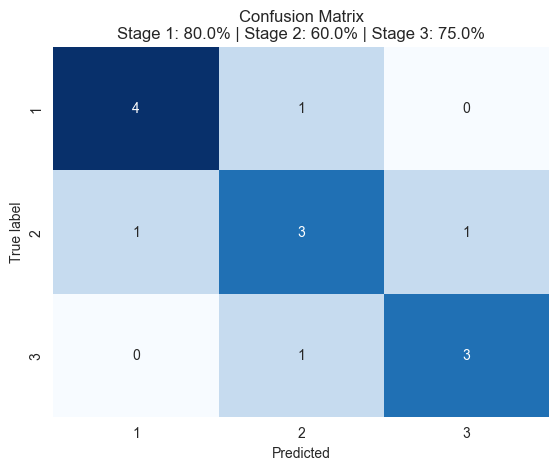

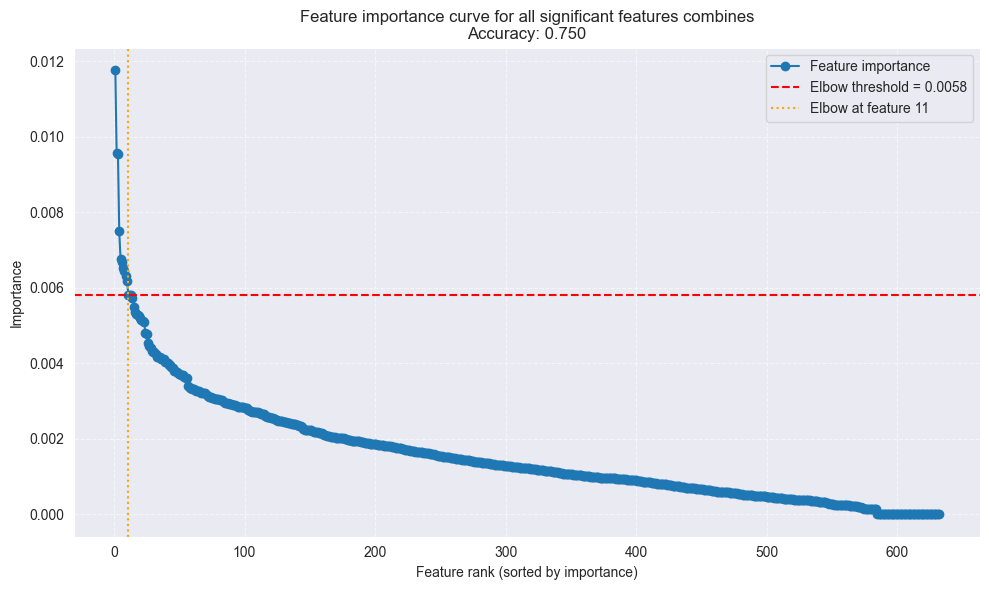

In [32]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1,'Stage 2': 2,'Stage 3': 3})
clinical_df = clinical_df.dropna(subset=['Stage'])
clinical_df['Stage'] = clinical_df['Stage'].astype(int)

X = combined_df
y = clinical_df['Stage']

valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print(feature_importance_df)

# cm = confusion_matrix(y_test, y_pred)
# class_accuracies = []
# for i in range(len(cm)):
#     total = cm[i].sum()
#     correct = cm[i, i]
#     acc = correct / total if total > 0 else 0
#     class_accuracies.append(acc)
#
# accuracy_text = " | ".join([
#     f"Stage {i + 1}: {class_accuracies[i] * 100:.1f}%"
#     for i in range(len(class_accuracies))
# ])
#
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#             xticklabels=[1, 2, 3], yticklabels=[1, 2, 3], cbar=False)
# plt.xlabel("Predicted")
# plt.ylabel("True label")
# plt.title(f"Confusion Matrix\n{accuracy_text}")
#
# imp = np.sort(feature_importance_df['Importance'].values)[::-1]
# x = np.arange(1, len(imp) + 1)
#
# knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
# threshold = imp[knee.knee] if knee.knee is not None else None
# selected_features = feature_importance_df[feature_importance_df['Importance'] > threshold]['Feature'].tolist()
# print(f"Selected features: {selected_features}")
#
# plt.figure(figsize=(10, 6))
# plt.plot(x, imp, marker='o', label='Feature importance')
# if threshold is not None:
#     plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
#     plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
# plt.title(f"Feature importance curve for all significant features combines\nAccuracy: {acc:.3f}")
# plt.xlabel("Feature rank (sorted by importance)")
# plt.ylabel("Importance")
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend()
# plt.tight_layout()
# plt.show()

In [47]:
from sklearn.ensemble import RandomForestRegressor
from feature_selection import Dataset
from sklearn.metrics import mean_squared_error, mean_absolute_error

m = Dataset()._merged_csvs()
clinical_column = "Calcium total level (mmol/l)"

for name, df in m.items():
    X = df.select_dtypes(include=['number'])
    y = clinical_df[clinical_column]

    valid_idx = X.notna().all(axis=1) & y.notna()
    X = X[valid_idx]
    y = y[valid_idx]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    rf = RandomForestRegressor(n_estimators=200, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} -> RMSE: {np.sqrt(mse):.3f} || MAE: {mae:.3f}")
    feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
    print(feature_importance_df)


BMD -> RMSE: 0.268 || MAE: 0.218
                                     Feature  Importance
29              original_firstorder_Skewness    0.208081
30           original_firstorder_TotalEnergy    0.058472
20              original_firstorder_Kurtosis    0.053746
17                original_firstorder_Energy    0.053424
53          original_glcm_MaximumProbability    0.035316
..                                       ...         ...
80   original_glszm_LowGrayLevelZoneEmphasis    0.000082
192       gradient_gldm_LowGrayLevelEmphasis    0.000082
133          gradient_glcm_DifferenceEntropy    0.000072
148                 gradient_glcm_SumEntropy    0.000052
163          gradient_glrlm_ShortRunEmphasis    0.000040

[201 rows x 2 columns]
CaSupp_25 -> RMSE: 0.314 || MAE: 0.259
                                    Feature  Importance
29             original_firstorder_Skewness    0.072026
53         original_glcm_MaximumProbability    0.064988
20             original_firstorder_Kurtosis    0.043